# Example model visualization

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')

import model

2026-04-13 21:57:23.851422: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-13 21:57:23.873152: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-13 21:57:23.897291: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-13 21:57:23.904311: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-13 21:57:23.924002: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


Task_sternberg_N_1000_Jitter_5_3_2026_04_13_211235.mat  

In [2]:
# find models in directory with specific name
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'
model_names = [model_name for model_name in os.listdir(model_dir) if '04_13_21' in model_name]
print(model_names)

['Task_sternberg_N_1000_Jitter_5_3_2026_04_13_211235.mat']


total trials: [[34901]]
final accuracy: load-1 0.96, load-3 0.92


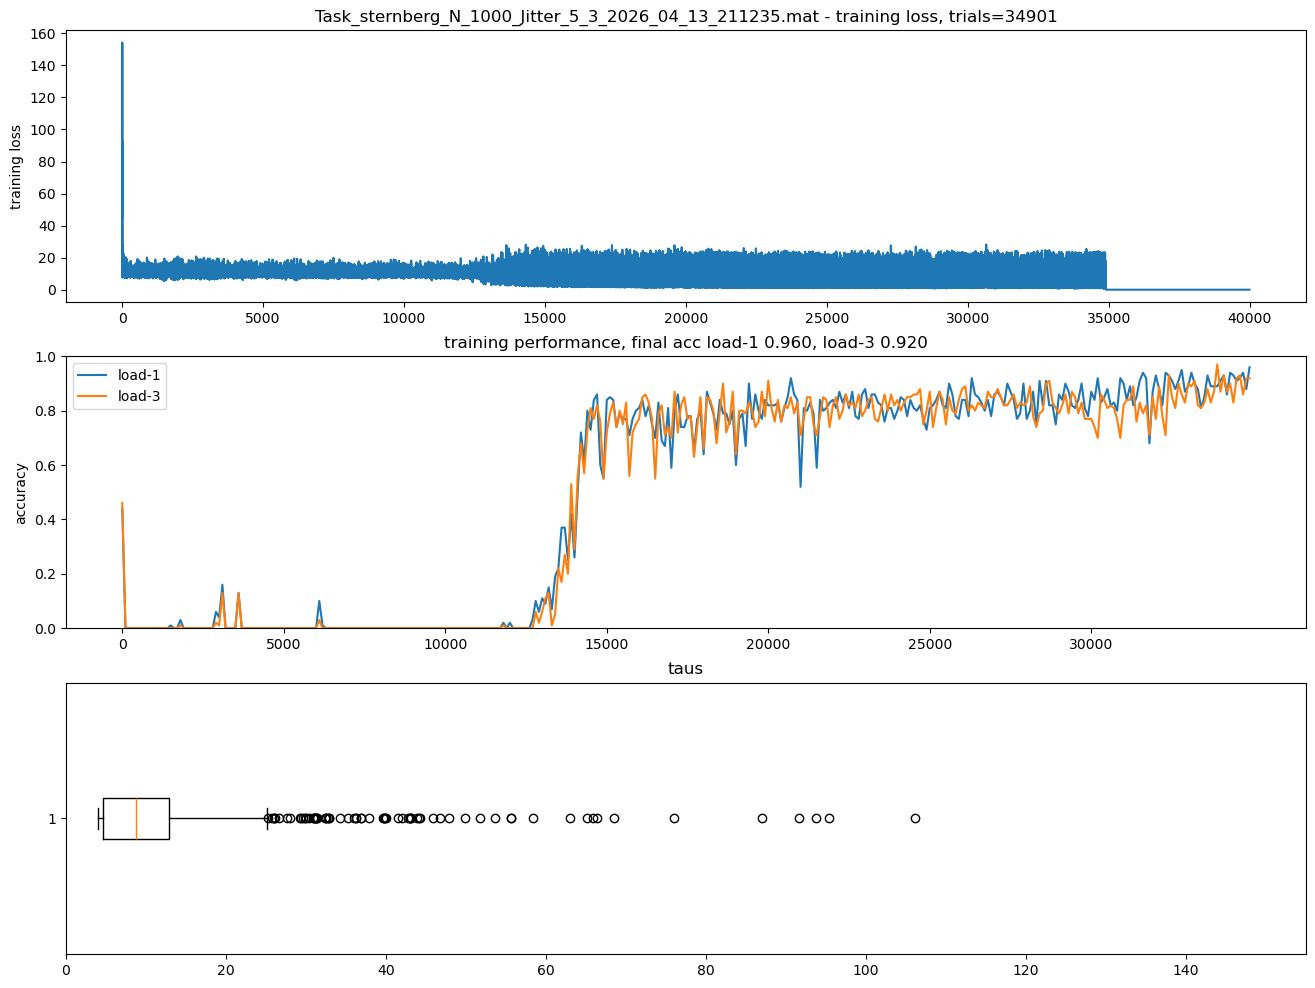

In [4]:
for model_fname in model_names:
    mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))
    
    print(f'total trials: {mat_data["tr"]}')
    
    eval_perfs_all = mat_data['eval_perfs_all']
    eval_perfs_all = eval_perfs_all.squeeze()
    print(f'final accuracy: load-1 {eval_perfs_all[-1,0]}, load-3 {eval_perfs_all[-1,1]}')
    
    fig, axs = plt.subplots(3, 1, figsize=(16,12))
    
    # subplot 1: training loss
    train_loss = mat_data['losses']
    train_loss = train_loss.squeeze()
    axs[0].plot(train_loss)
    axs[0].set_ylabel('training loss')
    axs[0].set_title(f'{model_fname} - training loss, trials={mat_data["tr"][0][0]}')
    
    # subplot 2: training performance on each load
    axs[1].plot(eval_perfs_all[:,0], label='load-1')
    axs[1].plot(eval_perfs_all[:,1], label='load-3')
    axs[1].set_title(f'training performance, final acc load-1 {eval_perfs_all[-1,0]:.3f}, load-3 {eval_perfs_all[-1,1]:.3f}')
    axs[1].set_ylabel('accuracy')
    axs[1].set_xticks(np.arange(0, len(eval_perfs_all), 50), labels=np.arange(0, len(eval_perfs_all), 50)*100)
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    
    # taus
    taus_gaus = mat_data['taus_gaus'].squeeze()
    taus = mat_data['taus'].squeeze()
    taus_sig = 1 / (1 + np.exp(-taus_gaus)) * (taus[1] - taus[0]) + taus[0]
    axs[2].boxplot(taus_sig, vert=False)
    axs[2].set_title('taus')
    axs[2].set_xlim(0, 155)
    # axs[2].set_xlabel('taus')

    # plt.suptitle(f'model: {model_fname}')



## one model

### load model

In [5]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'
model_fname = 'Task_sternberg_N_1000_Jitter_5_3_2026_04_13_211235.mat'
mat_data = scipy.io.loadmat(os.path.join(model_dir, model_fname))

[[34901]]


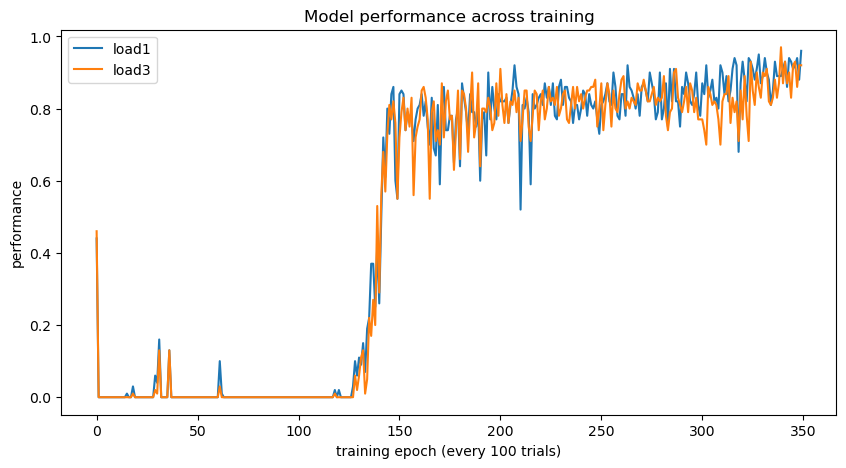

In [6]:
eval_perfs_all = mat_data['eval_perfs_all']
eval_perfs_all = eval_perfs_all.squeeze()
print(mat_data['tr'])

plt.figure(figsize=(10,5))
plt.plot(eval_perfs_all[:,0], label='load1')
plt.plot(eval_perfs_all[:,1], label='load3')
plt.xlabel('training epoch (every 100 trials)')
plt.ylabel('performance')
plt.legend()
plt.title('Model performance across training')
plt.show()

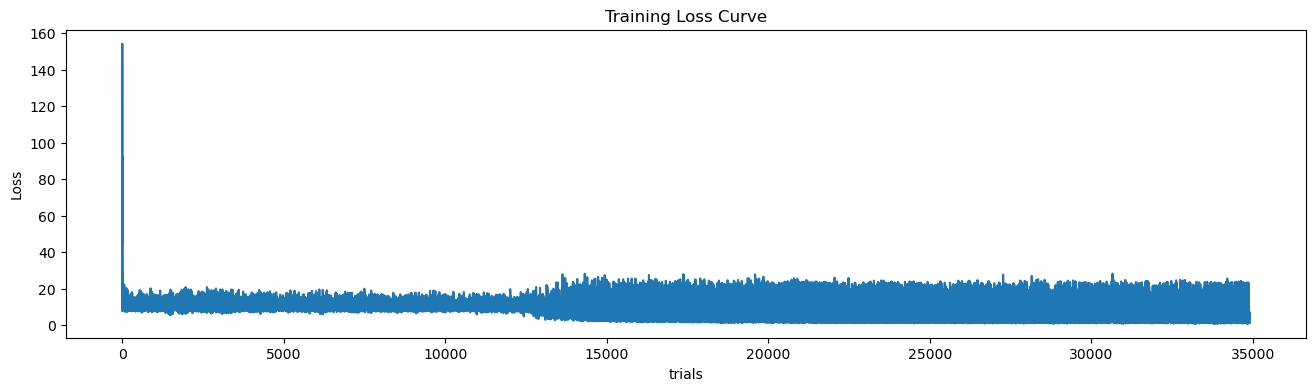

In [7]:
# plot training loss

losses = mat_data['losses'][0]
plt.figure(figsize=(16,4))
plt.plot(losses[:mat_data['tr'][0][0]])
plt.xlabel('trials')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.show()

### model eval

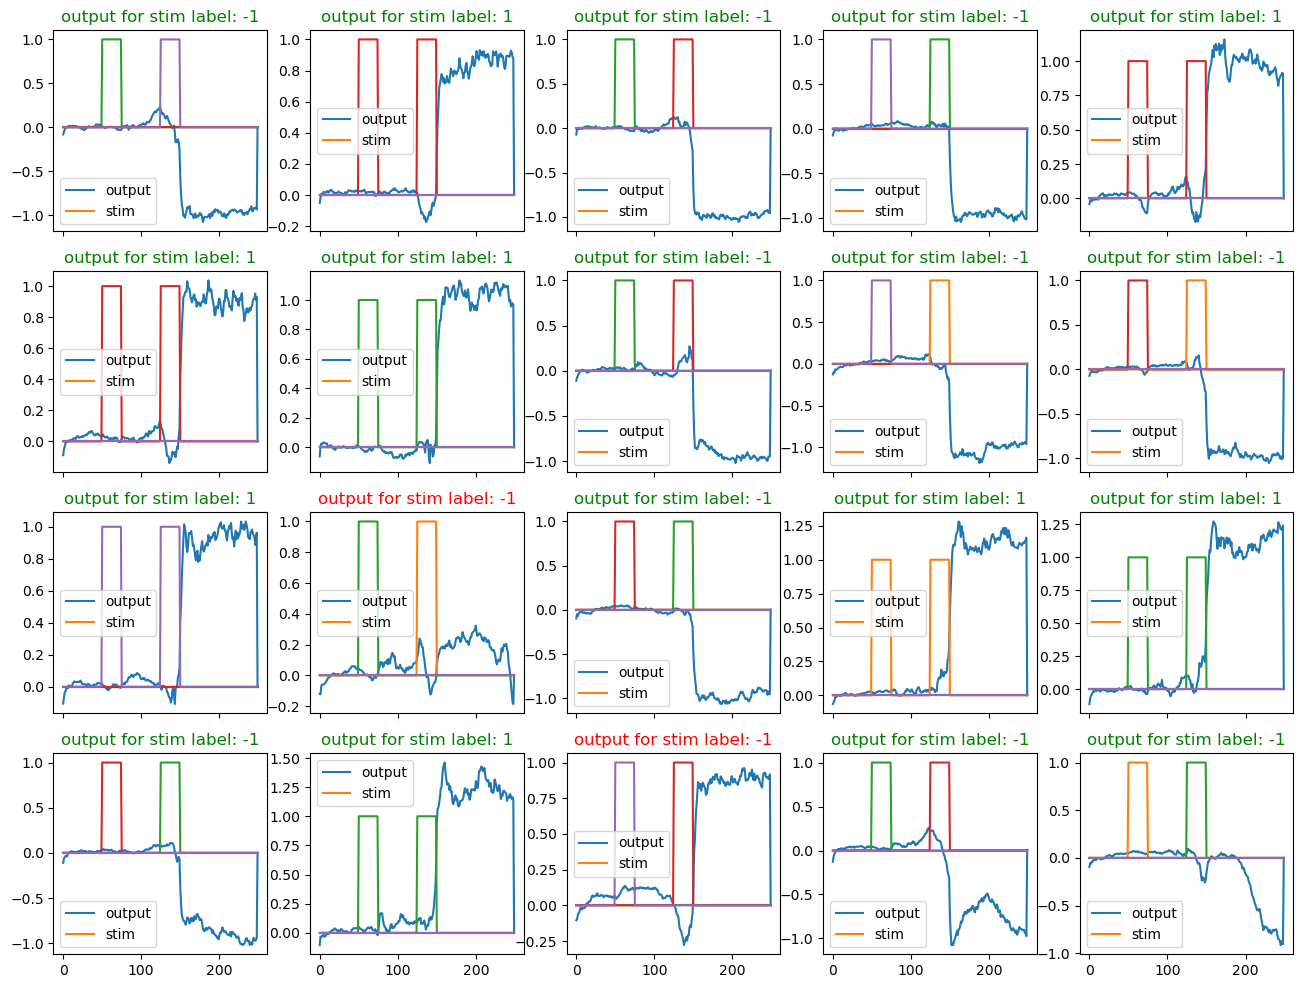

In [8]:
# low load, short delay
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 50, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1,
            }

resp_onset = settings['stim_on'] + settings['stim_dur']*(settings['load']+1) + settings['delay'] + 10
eval_amp_threshold = 0.7

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
    
    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    axs[j].set_title(f'output for stim label: {label}', color=title_color)
    axs[j].legend(['output','stim'])
plt.show()

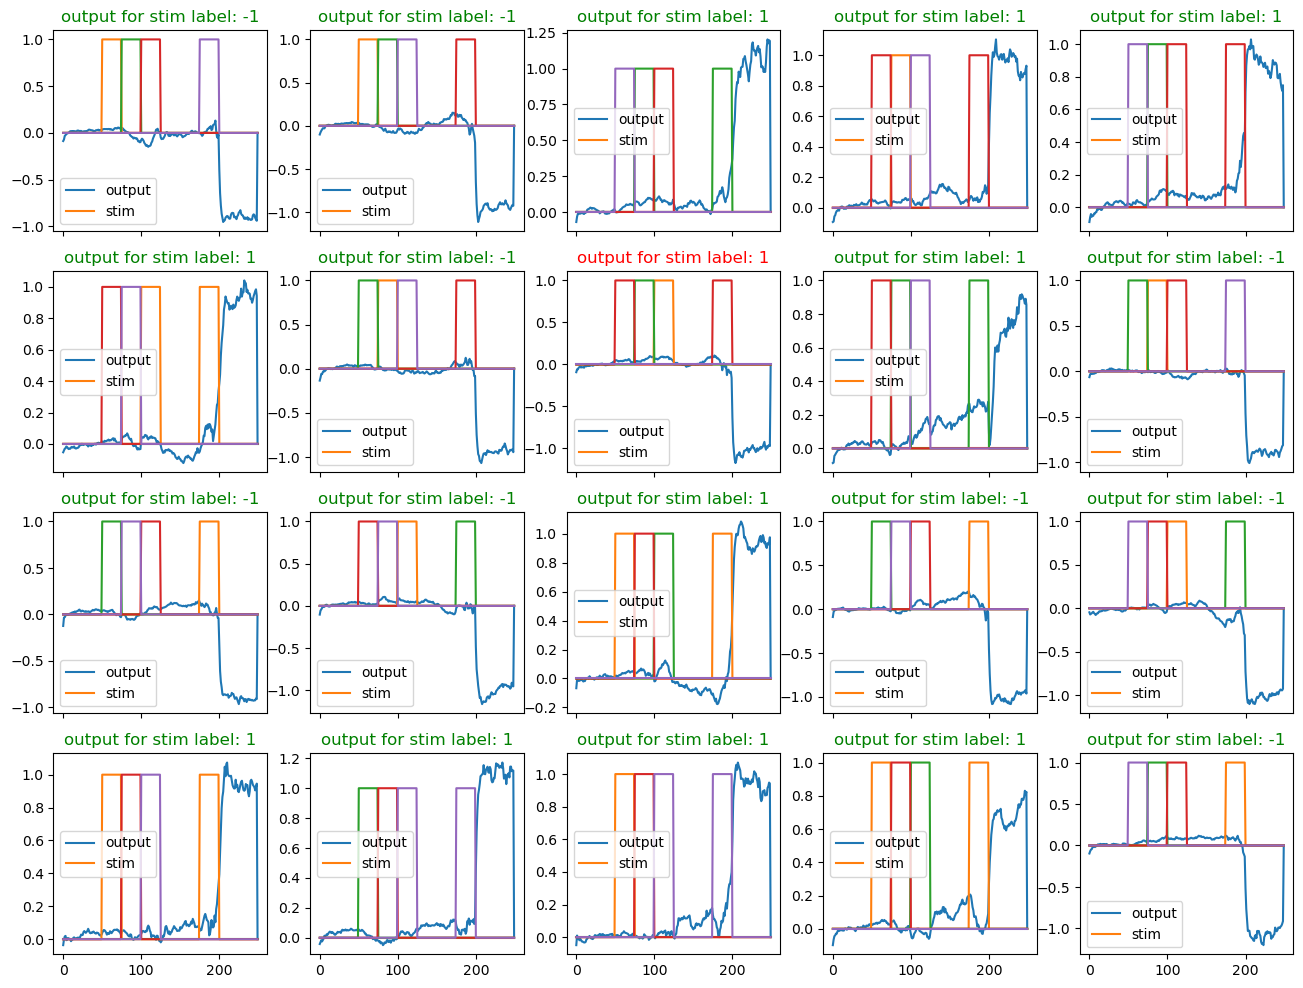

In [9]:
# high load, long delay
settings = {
            'T': 250, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 50, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

resp_onset = settings['stim_on'] + settings['stim_dur']*(settings['load']+1) + settings['delay'] + 10
eval_amp_threshold = 0.7

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
        
    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    axs[j].set_title(f'output for stim label: {label}', color=title_color)
    axs[j].legend(['output','stim'])
plt.show()

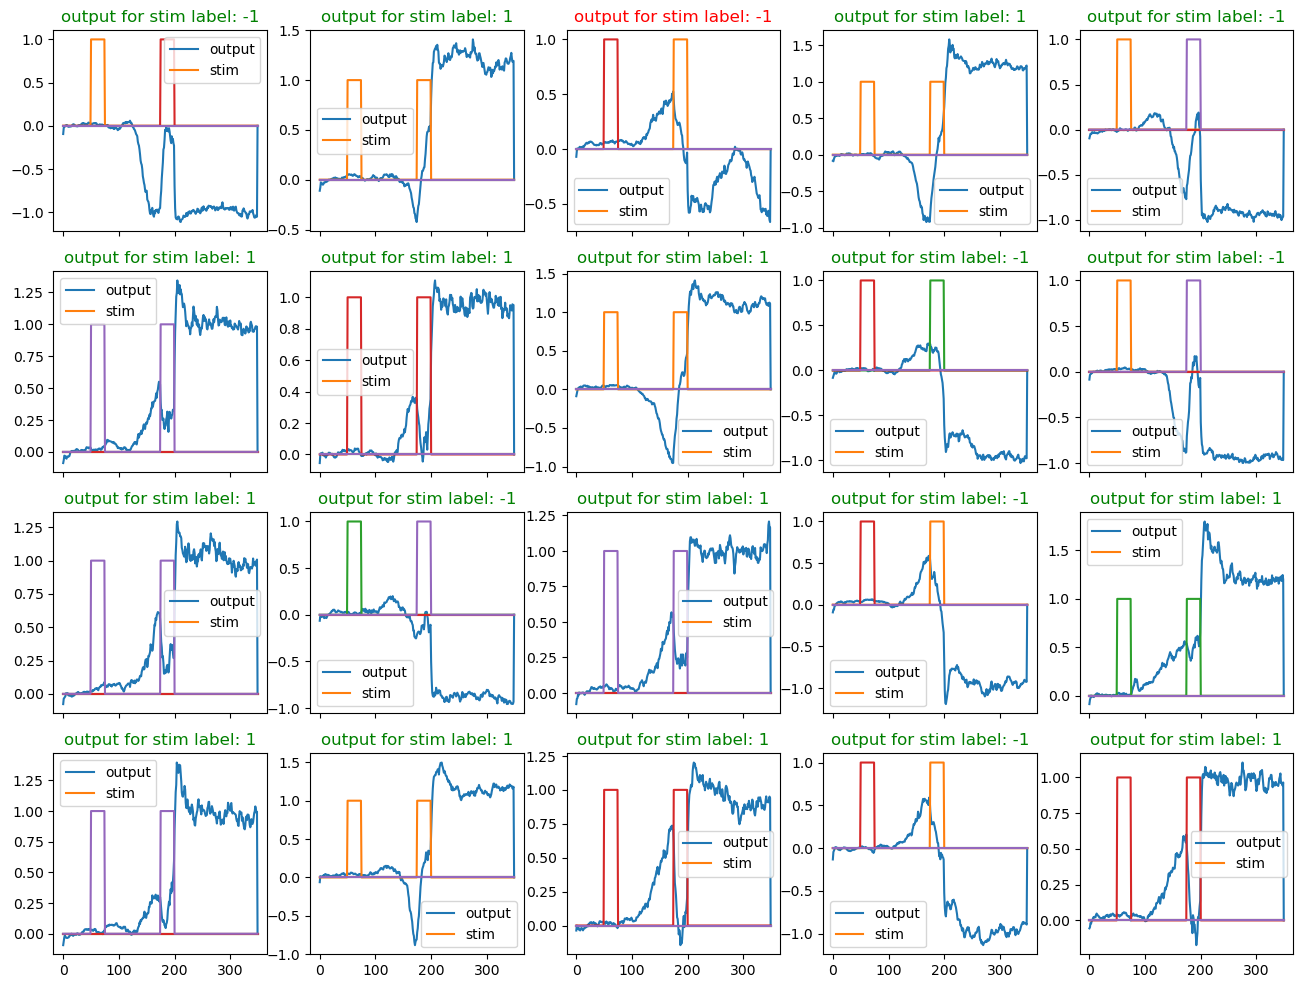

In [10]:
# low load, long delay
settings = {
            'T': 350, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 1,
            }

resp_onset = settings['stim_on'] + settings['stim_dur']*(settings['load']+1) + settings['delay'] + 10
eval_amp_threshold = 0.7

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
    
    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    axs[j].set_title(f'output for stim label: {label}', color=title_color)
    axs[j].legend(['output','stim'])
plt.show()

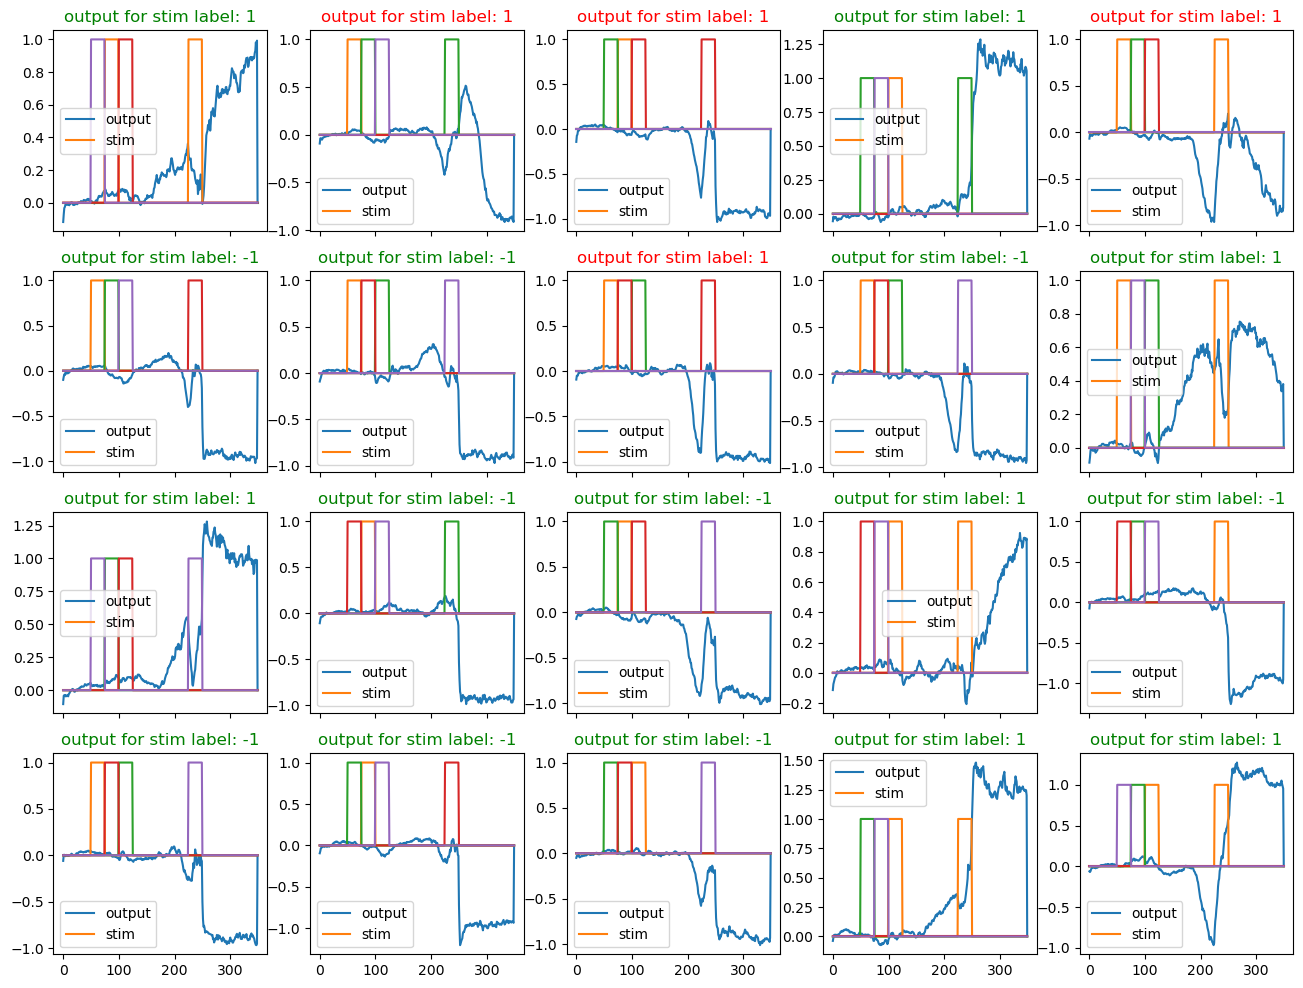

In [11]:
# high load, long delay
settings = {
            'T': 350, # trial duration (in steps)
            'stim_on': 50, # input stim onset (in steps)
            'stim_dur': 25, # input stim duration (in steps)
            'delay': 100, # delay b/w sample and test (in steps)
            'DeltaT': 1, # sampling rated
            'load': 3, # initialize with load 1, but will alternate with 3
            }

resp_onset = settings['stim_on'] + settings['stim_dur']*(settings['load']+1) + settings['delay'] + 10
eval_amp_threshold = 0.7

n_trials = 20
fig, axs = plt.subplots(4, 5, figsize=(16, 12), sharex=True)
axs = axs.flatten()
for j in range(n_trials):
    u_high, label = model.generate_input_stim_sternberg(settings)
    x, r, o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=u_high)

    axs[j].plot(o)
    for i in range(u_high.shape[0]):
        axs[j].plot(u_high[i,:])
        
    if label == 1:
        if np.max(o[resp_onset:]) > eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    else:
        if np.min(o[resp_onset:]) < -eval_amp_threshold:
            title_color = 'green'
        else:
            title_color = 'red'
    axs[j].set_title(f'output for stim label: {label}', color=title_color)
    axs[j].legend(['output','stim'])
plt.show()

In [ ]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + settings['stim_dur']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)

for i in range(n_trials):
    eval_u, eval_label = model.generate_input_stim_sternberg(settings)
    _, _, eval_o = model.eval_tf(model_dir=f'{model_dir}/{model_fname}', settings=settings, u=eval_u)
    if eval_label == 1:
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.max(np.abs(eval_o[resp_onset:])) < 0.3:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 1.00


### plotting model firing rates r, and synaptic current x

In [59]:
mat_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation'])

In [360]:
r = mat_data['r']
x = mat_data['x']
print(r.shape)
print(x.shape)

(200, 200, 1)
(200, 200, 1)


In [7]:
exc = mat_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = mat_data['inh']
inh_ind = np.where(inh == 1)[0]
print(inh_ind)

[  4   8   9  14  16  19  21  31  40  42  44  51  59  62  67  70  71  75
  76  77  80  88  92 101 102 103 107 121 123 124 129 130 132 133 138 142
 153 154 159 174 178 180 187 192 193 195]


### Trajectory plots

In [12]:

from sklearn.decomposition import PCA


In [13]:
r = mat_data['r'][:,:,0]
r.shape

(200, 200)

In [18]:
resp_onset = settings['stim_on'] + settings['stim_dur']

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [39]:
# X = USVt

pca = PCA(n_components=100).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(200, 100)
(100,)
(100, 200)


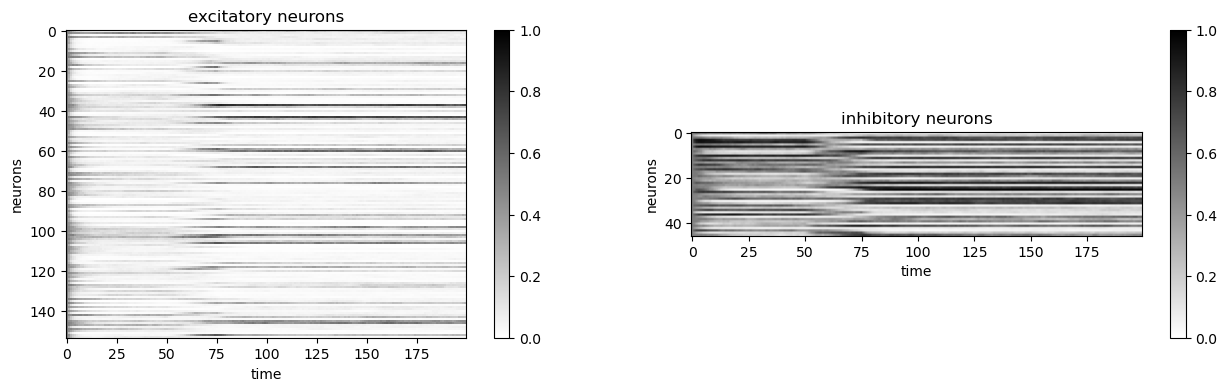

In [15]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

In [28]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

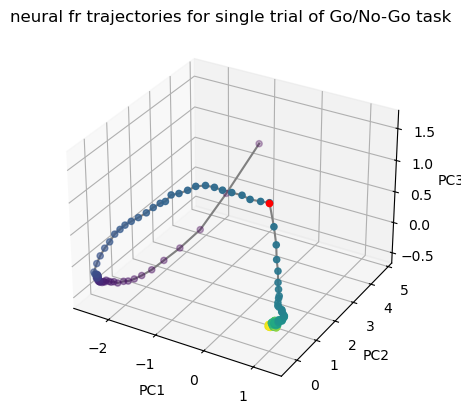

In [29]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(r_U[:,0], r_U[:,1], r_U[:,2], c=range(200))
ax.plot3D(r_U[:,0], r_U[:,1], r_U[:,2], 'gray')
ax.scatter(r_U[resp_onset,0], r_U[resp_onset,1], r_U[resp_onset,2], c='r')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('neural fr trajectories for single trial of Go/No-Go task')
plt.show()